<a href="https://colab.research.google.com/github/AvirupVIP/SIGNIFY---Signature-Forgery-Detection-System/blob/master/Mobilenet_Soumyadipto_modified.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install tensorflow scikit-learn matplotlib

In [3]:
from google.colab import files
uploaded = files.upload()

Saving processed_signature.zip to processed_signature.zip


In [4]:
import zipfile

zip_path = "processed_signature.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content")

print("Dataset Extracted!")

Dataset Extracted!


In [29]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Input, Dense, GlobalAveragePooling2D, Lambda
from tensorflow.keras.layers import BatchNormalization, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras import backend as K
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.metrics import precision_score, recall_score, f1_score

In [32]:
csv_path = None

for root, dirs, files in os.walk("/content"):
    for file in files:
        if file == "signature_dataset.csv":
            csv_path = os.path.join(root,file)
            break
    if csv_path:
        break

print("CSV FOUND:", csv_path)

df = pd.read_csv(csv_path)

print(df.head())
print(df.columns)

base_path = os.path.dirname(csv_path)

print("Base path:", base_path)

CSV FOUND: /content/processed_signatures/data/processed/signature_dataset.csv
             image_path  person_id  label  split
0  train/031/05_031.png         31      0  train
1  train/031/07_031.png         31      0  train
2  train/031/11_031.png         31      0  train
3  train/031/08_031.png         31      0  train
4  train/031/12_031.png         31      0  train
Index(['image_path', 'person_id', 'label', 'split'], dtype='object')
Base path: /content/processed_signatures/data/processed


In [33]:
def load_image(img_path):

    img = image.load_img(os.path.join(base_path,img_path),target_size=(224,224))
    img = image.img_to_array(img)

    img = img/255.0

    return img

In [34]:
train_df = df[df["split"]=="train"]
test_df  = df[df["split"]=="test"]

print("Train samples:",len(train_df))
print("Test samples:",len(test_df))

Train samples: 1649
Test samples: 500


In [35]:
def create_pairs(dataframe):

    pairs=[]
    labels=[]

    grouped=dataframe.groupby("person_id")

    for person_id,group in grouped:

        genuine=group[group["label"]==1]["image_path"].values
        forged=group[group["label"]==0]["image_path"].values

        # genuine pairs
        for i in range(len(genuine)-1):

            img1=load_image(genuine[i])
            img2=load_image(genuine[i+1])

            pairs.append([img1,img2])
            labels.append(1)

        # forged pairs
        for i in range(min(len(genuine),len(forged))):

            img1=load_image(genuine[i])
            img2=load_image(forged[i])

            pairs.append([img1,img2])
            labels.append(0)

    return np.array(pairs),np.array(labels)

In [36]:
train_pairs,train_labels=create_pairs(train_df)

print("Train pairs:",len(train_pairs))

Train pairs: 1417


In [37]:
test_pairs,test_labels=create_pairs(test_df)

print("Test pairs:",len(test_pairs))

Test pairs: 451


In [38]:
X_train=train_pairs
y_train=train_labels

X_test=test_pairs
y_test=test_labels

In [39]:
def build_embedding_model():

    base_model=MobileNetV2(
        weights="imagenet",
        include_top=False,
        input_shape=(224,224,3)
    )

    # fine tune last layers
    for layer in base_model.layers[:-20]:
        layer.trainable=False

    x=base_model.output
    x=GlobalAveragePooling2D()(x)

    x=Dense(256,activation="relu")(x)
    x=BatchNormalization()(x)
    x=Dropout(0.5)(x)

    x=Dense(128,activation="relu")(x)

    model=Model(base_model.input,x)

    return model

In [40]:
def euclidean_distance(vectors):

    x,y=vectors

    return K.sqrt(K.sum(K.square(x-y),axis=1,keepdims=True))

In [41]:
def contrastive_loss(y_true,y_pred):

    margin=1

    square_pred=K.square(y_pred)
    margin_square=K.square(K.maximum(margin-y_pred,0))

    return K.mean(y_true*square_pred+(1-y_true)*margin_square)

In [42]:
embedding_model=build_embedding_model()

input_a=Input(shape=(224,224,3))
input_b=Input(shape=(224,224,3))

embedding_a=embedding_model(input_a)
embedding_b=embedding_model(input_b)

distance=Lambda(euclidean_distance)([embedding_a,embedding_b])

siamese_model=Model([input_a,input_b],distance)

siamese_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss=contrastive_loss,
    metrics=["accuracy"]
)

siamese_model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_5       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional_2        │ (None, 128)       │  2,619,840 │ input_layer_4[0]… │
│ (Functional)        │                   │            │ input_layer_5[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 1)         │          0 │ functional_2[0][… │
│                     │                   │            │ functional_2[1][… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,619,840 (9.99 MB)

 Trainable params: 1,567,424 (5.98 MB)

 Non-trainable params: 1,052,416 (4.01 MB)

In [43]:
early_stop=EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

reduce_lr=ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=3,
    min_lr=1e-6
)

In [44]:
history=siamese_model.fit(

    [X_train[:,0],X_train[:,1]],
    y_train,

    validation_data=([X_test[:,0],X_test[:,1]],y_test),

    epochs=20,
    batch_size=16,

    callbacks=[early_stop,reduce_lr]
)

Epoch 1/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 181s 2s/step - accuracy: 0.5126 - loss: 91.0254 - val_accuracy: 0.5033 - val_loss: 20.1368 - learning_rate: 1.0000e-04
Epoch 2/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 164s 2s/step - accuracy: 0.4842 - loss: 59.9822 - val_accuracy: 0.5033 - val_loss: 25.0530 - learning_rate: 1.0000e-04
Epoch 3/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 206s 2s/step - accuracy: 0.4900 - loss: 47.4739 - val_accuracy: 0.5033 - val_loss: 19.5676 - learning_rate: 1.0000e-04
Epoch 4/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 193s 2s/step - accuracy: 0.4782 - loss: 38.0909 - val_accuracy: 0.5033 - val_loss: 13.8733 - learning_rate: 1.0000e-04
Epoch 5/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 158s 2s/step - accuracy: 0.5110 - loss: 35.8339 - val_accuracy: 0.5033 - val_loss: 10.3128 - learning_rate: 1.0000e-04
Epoch 6/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 205s 2s/step - accuracy: 0.4772 - loss: 29.6468 - val_accuracy: 0.5033 - val_loss: 5.9745 - learning_rate: 1.0000e-04
Epoch 7/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 158s 2s/step - accura

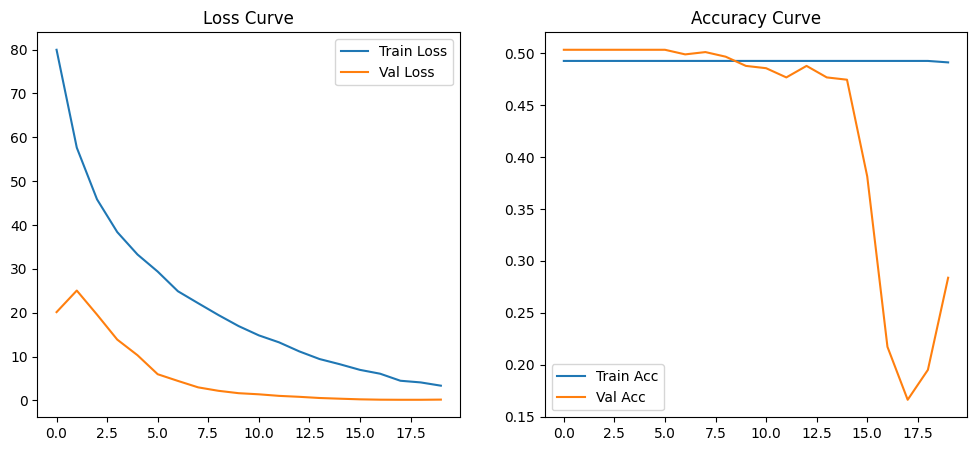

In [45]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history["loss"],label="Train Loss")
plt.plot(history.history["val_loss"],label="Val Loss")
plt.legend()
plt.title("Loss Curve")

plt.subplot(1,2,2)
plt.plot(history.history["accuracy"],label="Train Acc")
plt.plot(history.history["val_accuracy"],label="Val Acc")
plt.legend()
plt.title("Accuracy Curve")

plt.show()

In [46]:
distances=siamese_model.predict([X_test[:,0],X_test[:,1]])

15/15 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step


In [47]:
genuine_dist=distances[y_test==1]
forged_dist=distances[y_test==0]

print("Mean Genuine Distance:",np.mean(genuine_dist))
print("Mean Forged Distance:",np.mean(forged_dist))

Mean Genuine Distance: 0.1912804
Mean Forged Distance: 1.1855724


In [48]:
thresholds=np.linspace(0,2,100)

best_acc=0
best_thresh=0

for t in thresholds:

    preds=(distances<t).astype(int)

    acc=np.mean(preds.flatten()==y_test)

    if acc>best_acc:
        best_acc=acc
        best_thresh=t

print("Best Threshold:",best_thresh)
print("Best Accuracy:",best_acc)

Best Threshold: 0.3434343434343435
Best Accuracy: 0.8492239467849224


In [49]:
predictions=(distances<best_thresh).astype(int)

precision=precision_score(y_test,predictions)
recall=recall_score(y_test,predictions)
f1=f1_score(y_test,predictions)

print("Precision:",precision)
print("Recall:",recall)
print("F1 Score:",f1)

Precision: 0.8022813688212928
Recall: 0.9295154185022027
F1 Score: 0.8612244897959184


In [50]:
confidence=1-(distances/np.max(distances))

print("Average Confidence:",np.mean(confidence))

Average Confidence: 0.9135742


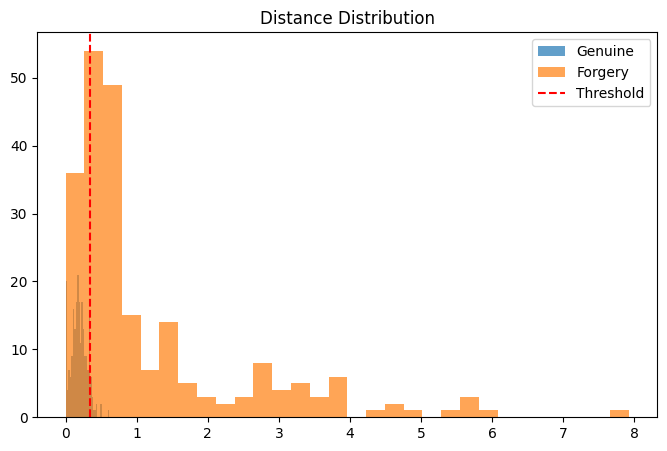

In [51]:
plt.figure(figsize=(8,5))

plt.hist(genuine_dist,bins=30,alpha=0.7,label="Genuine")
plt.hist(forged_dist,bins=30,alpha=0.7,label="Forgery")

plt.axvline(best_thresh,color="red",linestyle="--",label="Threshold")

plt.legend()
plt.title("Distance Distribution")

plt.show()

In [52]:
siamese_model.save("signature_siamese_model.h5")

print("Model saved")

Model saved
